# Генерация текстовых данных через β-VAE

**Пайплайн:** `dataset` → `SentenceTransformer (all-MiniLM-L6-v2)` → `β-VAE` → синтетические эмбеддинги → seq2seq декодирование → валидация

Вся реализация вынесена в пакет `synthetic_vae/`. Ноутбук отвечает только за конфигурацию и демонстрацию результатов.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/data-quality-process/orlov-alexander')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%pip install sentence-transformers torch transformers sentencepiece scipy scikit-learn --quiet

In [3]:
import sys
#sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from synthetic_vae import SyntheticEmbeddingPipeline


plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_columns', None)
print('import success.')

import success.


## Предобработка данных

In [4]:
RAW_PATH     = '/content/drive/MyDrive/data-quality-process//data/test.csv'
df_raw = pd.read_csv(RAW_PATH)

N_SAMPLES    = 10000
RANDOM_STATE = 42

df = (
    df_raw.iloc[:, 1:]
    .drop_duplicates(keep='first')
    .dropna()
    .sample(n=N_SAMPLES, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print(f'df.shape: {df.shape}')
df.head(2)

df.shape: (10000, 2)


,article,highlights
0,A Hollywood-inspired experiment to help dement...,Residents at Hebrew Care Home in New York are ...
1,Eerie footage has emerged showing a mysterious...,Clip shows mysterious black cloud hanging over...


In [5]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

pipeline = SyntheticEmbeddingPipeline(
    model_name       = 'sentence-transformers/all-MiniLM-L6-v2',
    local_model_path = '/content/drive/MyDrive/data-quality-process/orlov-alexander/models/all-MiniLM-L6-v2',
    hidden_dim       = 128,
    latent_dim       = 50,
    batch_size       = 128,
    epochs           = 300,
    lr               = 1e-4,
    num_synthetic    = 10000,
    base_beta        = 0.01,
    max_beta         = 0.05,
    warmup_ratio     = 0.3,
    device           = device,
    verbose          = True,
)
print(f'Device: {pipeline.device}')

Device: cuda


In [6]:
pipeline.fit(df)

load model from local cache: /content/drive/MyDrive/data-quality-process/orlov-alexander/models/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

  vectorize col 'article'...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

  → shape: (10000, 384)
  vectorize col 'highlights'...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

  → shape: (10000, 384)
    column  n_entries  vector_dim  overall_mean  overall_std
   article      10000         384     -0.000806     0.047487
highlights      10000         384     -0.000682     0.048402
  [article] epoch   1/300  β=0.0000  loss=34.2826
  [article] epoch  11/300  β=0.0056  loss=22.4820
  [article] epoch  21/300  β=0.0111  loss=19.3123
  [article] epoch  31/300  β=0.0167  loss=17.9186
  [article] epoch  41/300  β=0.0222  loss=17.3376
  [article] epoch  51/300  β=0.0278  loss=17.2176
  [article] epoch  61/300  β=0.0333  loss=17.3012
  [article] epoch  71/300  β=0.0389  loss=17.4683
  [article] epoch  81/300  β=0.0444  loss=17.6754
  [article] epoch  91/300  β=0.0500  loss=17.9016
  [article] epoch 101/300  β=0.0500  loss=17.7126
  [article] epoch 111/300  β=0.0500  loss=17.5508
  [article] epoch 121/300  β=0.0500  loss=17.4162
  [article] epoch 131/300  β=0.0500  loss=17.2856
  [article] epoch 141/300  β=0.0500  loss=17.1977
  [article] epoch 151/300  β=0.0500  loss=1

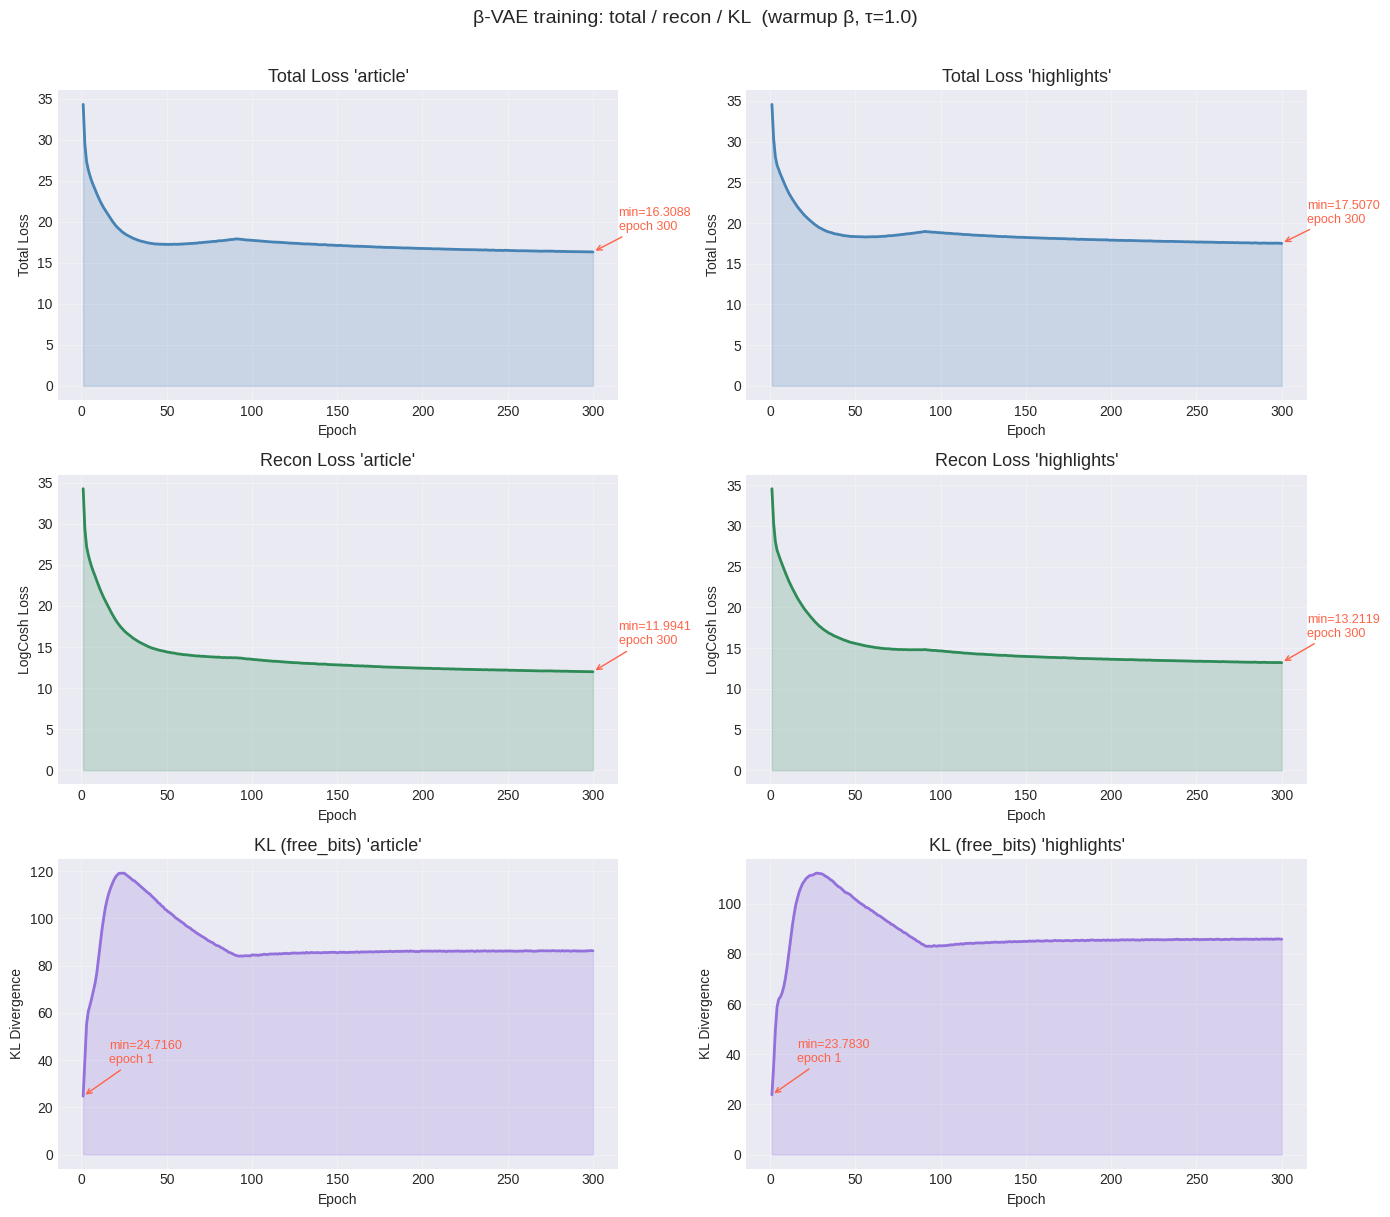

In [7]:
n_cols = len(pipeline.synthetic_data_)
fig, axes = plt.subplots(3, n_cols, figsize=(7 * n_cols, 12))

if n_cols == 1:
    axes = axes.reshape(3, 1)

for col_idx, (_, row) in enumerate(pipeline.synthetic_data_.iterrows()):
    col           = row['column']
    loss_history  = row['loss_history']
    recon_history = row['recon_history']
    kl_history    = row['kl_history']
    epochs_range  = range(1, len(loss_history) + 1)

    def plot_curve(ax, history, color, title, ylabel):
        ax.fill_between(epochs_range, history, alpha=0.2, color=color)
        ax.plot(epochs_range, history, color=color, lw=2)
        ax.set_title(f"{title} '{col}'", fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

        min_epoch = int(np.argmin(history)) + 1
        min_val   = min(history)
        ax.annotate(
            f'min={min_val:.4f}\nepoch {min_epoch}',
            xy=(min_epoch, min_val),
            xytext=(
                min_epoch + len(history) * 0.05,
                min_val + (max(history) - min(history)) * 0.15,
            ),
            arrowprops=dict(arrowstyle='->', color='tomato'),
            fontsize=9, color='tomato',
        )

    plot_curve(axes[0, col_idx], loss_history,  'steelblue', 'Total Loss',  'Total Loss')
    plot_curve(axes[1, col_idx], recon_history, 'seagreen',  'Recon Loss',  'LogCosh Loss')
    plot_curve(axes[2, col_idx], kl_history,    'mediumpurple', 'KL (free_bits)', 'KL Divergence')

plt.suptitle('β-VAE training: total / recon / KL  (warmup β, τ=1.0)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Основные стат. моменты эмбеддингов оригинальных данных

In [8]:
scalar_cols = ['column', 'n_entries', 'vector_dim',
               'overall_mean', 'overall_std',
               'overall_q25', 'overall_q50', 'overall_q75', 'overall_iqr']
pipeline.summary_df_[scalar_cols]

,column,n_entries,vector_dim,overall_mean,overall_std,overall_q25,overall_q50,overall_q75,overall_iqr
0,article,10000,384,-0.000806,0.047487,-0.032984,-0.000780,0.031424,0.064408
1,highlights,10000,384,-0.000682,0.048402,-0.033440,-0.000649,0.032121,0.065560


## Валидация

In [9]:
pivot_df, detailed_df, wasserstein_df = pipeline.validate(n_wasserstein_projections=100)

In [10]:
pivot_df

metric,article,highlights
mean_mae,0.004253,0.004370
std_mae,0.009913,0.011055
q25_mae,0.007419,0.007886
q50_mae,0.004348,0.004543
q75_mae,0.007368,0.008112
iqr_mae,0.013391,0.014852
skew_mae,0.058252,0.059984
kurt_mae,0.086124,0.081813
mean_rel_mae,0.307909,0.381177
std_rel_mae,0.208752,0.228397


In [11]:
wasserstein_df

,column,sliced_wasserstein,baseline_distance,normalized_swd
0,article,0.008806,1.324846,0.006647
1,highlights,0.009814,1.347851,0.007281


In [12]:
score_cols = [
    'column', 'composite_score', 'composite_score_with_swd',
    'sliced_wasserstein', 'normalized_swd',
    'centr_cos_sim', 'syn_diversity_avg', 'orig_diversity_avg',
    'mean_rel_mae', 'std_rel_mae'
]
detailed_df[score_cols]

,column,composite_score,composite_score_with_swd,sliced_wasserstein,normalized_swd,centr_cos_sim,syn_diversity_avg,orig_diversity_avg,mean_rel_mae,std_rel_mae
0,article,0.247942,0.213471,0.008806,0.006647,0.954043,0.818934,0.879378,0.307909,0.208752
1,highlights,0.285105,0.245416,0.009814,0.007281,0.937548,0.849924,0.913198,0.381177,0.228397


In [13]:
detailed_df.T

,0,1
column,article,highlights
n_original,10000,10000
n_synthetic,10000,10000
vector_dim,384,384
collapsed_dims,2,2
...,...,...
sliced_wasserstein,0.008806,0.009814
baseline_distance,1.324846,1.347851
normalized_swd,0.006647,0.007281
normalized_swd_capped,0.006647,0.007281


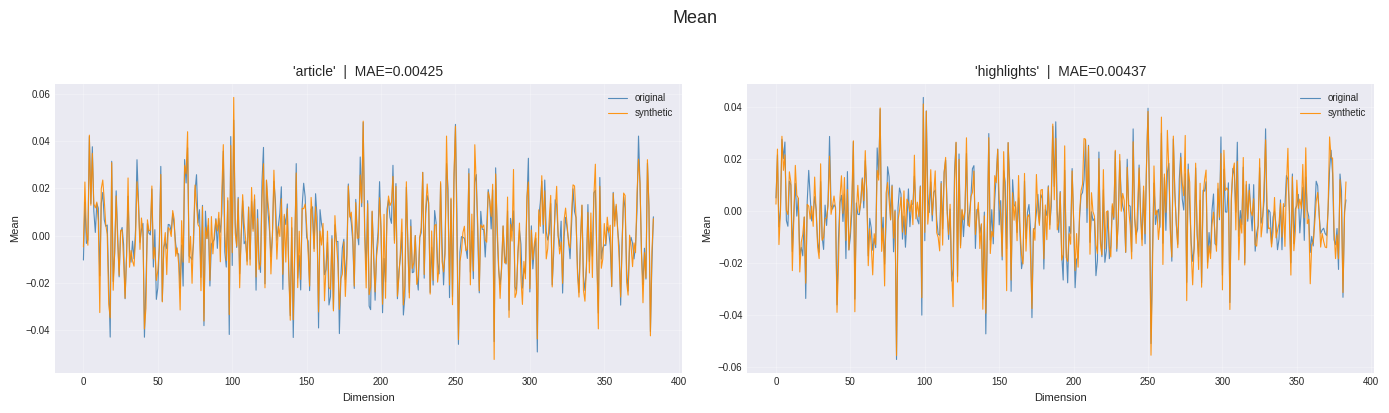

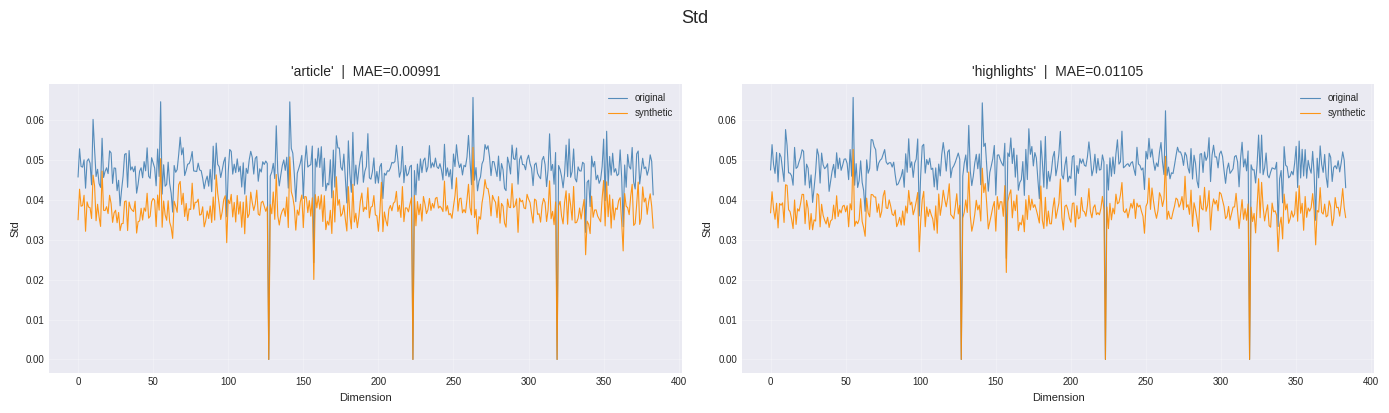

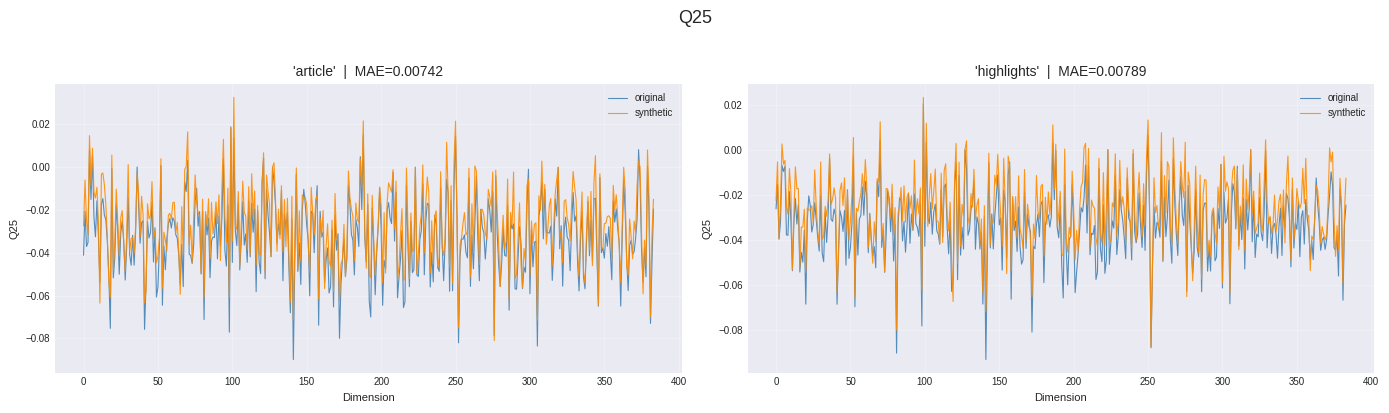

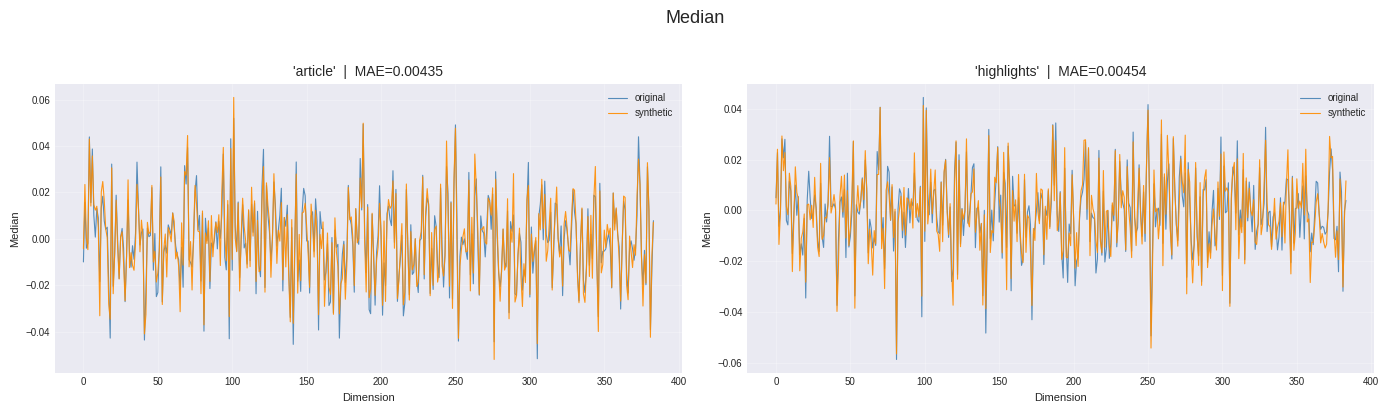

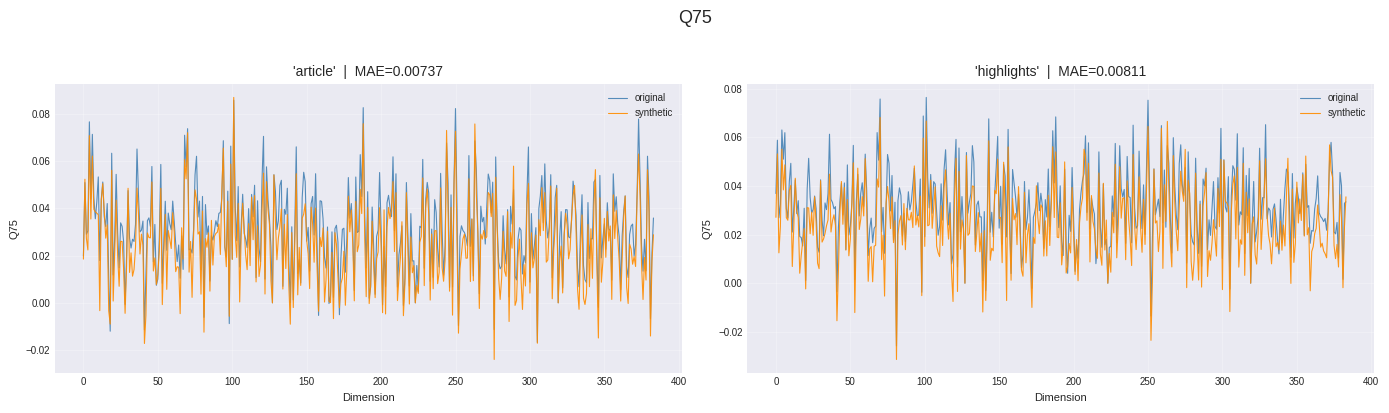

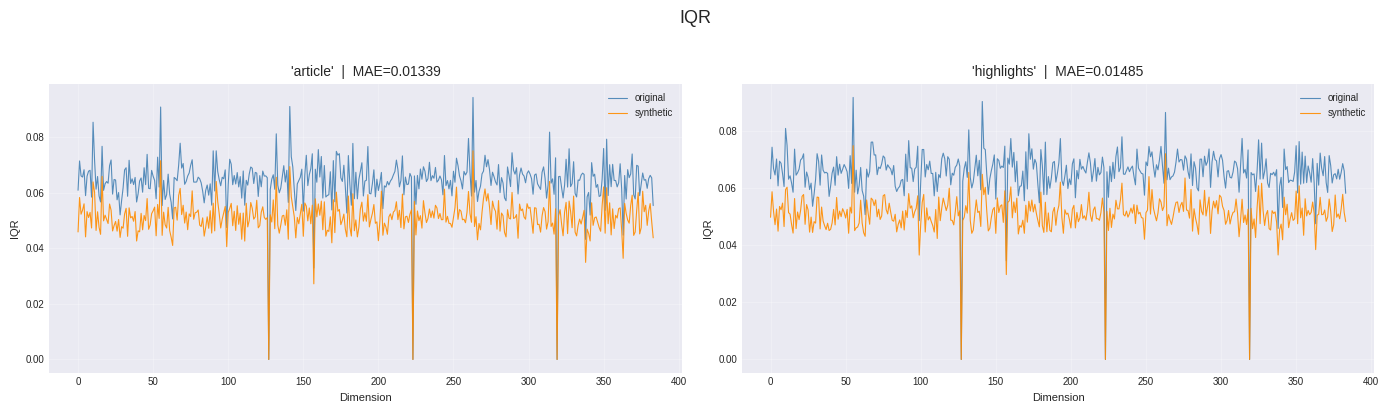

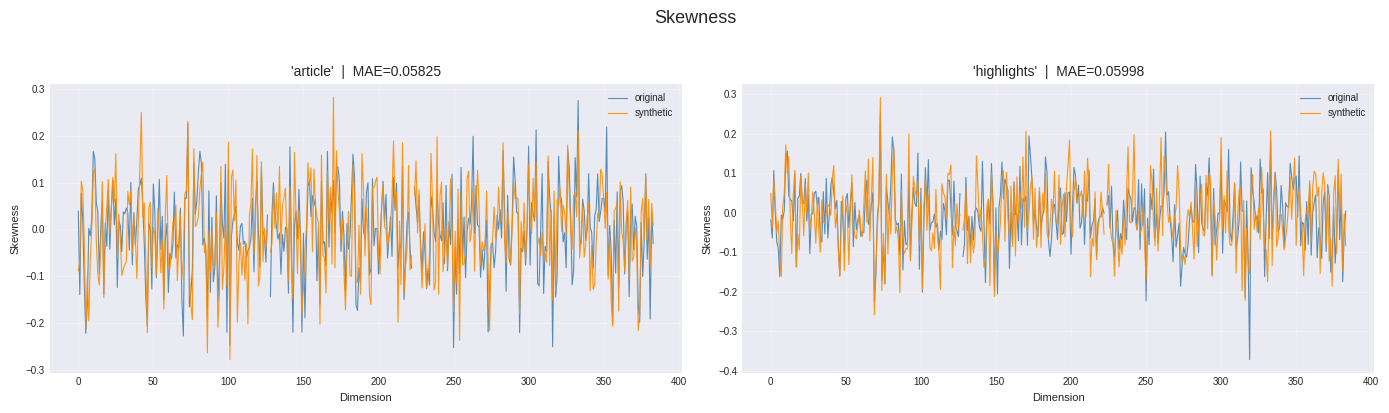

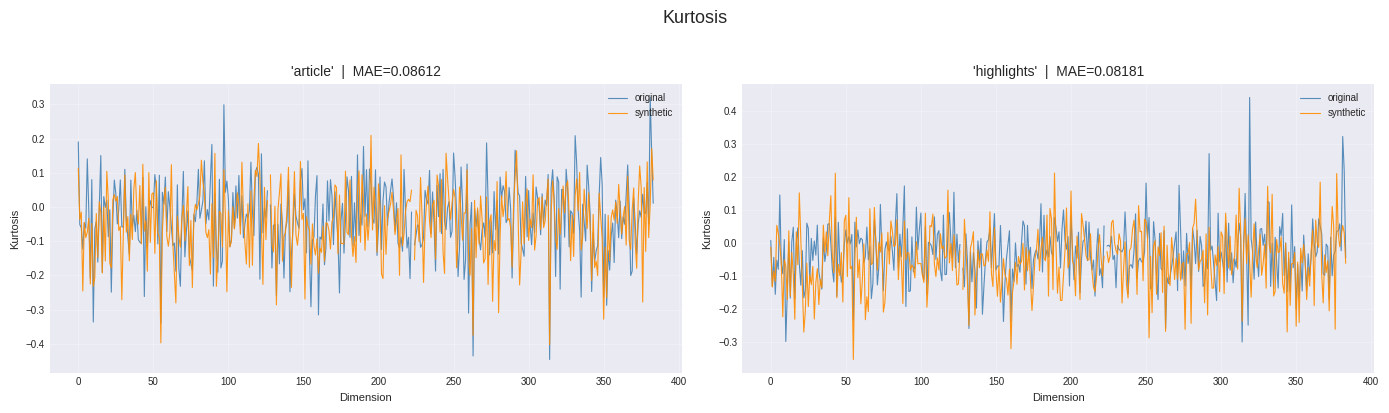

In [14]:
STATS_TO_PLOT = [
    ('Mean',     '_orig_mean_vec',  '_syn_mean_vec',  'mean_mae'),
    ('Std',      '_orig_std_vec',   '_syn_std_vec',   'std_mae'),
    ('Q25',      '_orig_q25_vec',   '_syn_q25_vec',   'q25_mae'),
    ('Median',   '_orig_q50_vec',   '_syn_q50_vec',   'q50_mae'),
    ('Q75',      '_orig_q75_vec',   '_syn_q75_vec',   'q75_mae'),
    ('IQR',      '_orig_iqr_vec',   '_syn_iqr_vec',   'iqr_mae'),
    ('Skewness', '_orig_skew_vec',  '_syn_skew_vec',  'skew_mae'),
    ('Kurtosis', '_orig_kurt_vec',  '_syn_kurt_vec',  'kurt_mae'),
]

cols = detailed_df['column'].tolist()
dims = np.arange(384)

for stat_name, orig_key, syn_key, mae_key in STATS_TO_PLOT:
    n_cols = len(cols)
    fig, axes = plt.subplots(
        1, n_cols,
        figsize=(7 * n_cols, 4),
        squeeze=False
    )

    for col_idx, col in enumerate(cols):
        row_data = detailed_df[detailed_df['column'] == col].iloc[0]
        ax = axes[0][col_idx]

        orig_vec = np.array(row_data[orig_key])
        syn_vec  = np.array(row_data[syn_key])
        mae_val  = row_data.get(mae_key, float('nan'))

        if stat_name in ('Skewness', 'Kurtosis'):
            mask     = ~np.isnan(orig_vec) & ~np.isnan(syn_vec)
            orig_vec = np.where(mask, orig_vec, np.nan)
            syn_vec  = np.where(mask, syn_vec,  np.nan)

        ax.plot(dims, orig_vec, color='steelblue',  linewidth=0.8,
                alpha=0.9, label='original')
        ax.plot(dims, syn_vec,  color='darkorange', linewidth=0.8,
                alpha=0.9, label='synthetic')

        ax.set_title(
            f"'{col}'  |  MAE={mae_val:.5f}",
            fontsize=10
        )
        ax.set_xlabel('Dimension', fontsize=8)
        ax.set_ylabel(stat_name, fontsize=8)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.25)
        ax.tick_params(labelsize=7)

    fig.suptitle(stat_name, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

Синтетические эмбеддинги доступны как `dict[str, np.ndarray]` для дальнейшего использования.

In [15]:
synthetic_embeddings = pipeline.get_synthetic_embeddings()

for col, emb in synthetic_embeddings.items():
    print(f'{col}: shape={emb.shape},  mean={emb.mean():.6f},  std={emb.std():.6f}')

article: shape=(10000, 384),  mean=-0.000847,  std=0.041965
highlights: shape=(10000, 384),  mean=-0.000697,  std=0.040831


## Обучение seq2seq декодера

Декодер обучается на парах *(оригинальный эмбеддинг, оригинальный текст)* из входного датасета.
Гиперпараметры (число эпох, `max_new_tokens`) выбираются автоматически по размеру выборки и длине текстов.

Базовая модель — **T5-small** (60M params), альтернативная — **google/t5-efficient-tiny** (4B params) для быстрой генерации.

In [16]:
DECODE_COLS = None

pipeline.fit_decoder(
    df,
    text_cols          = DECODE_COLS,
    decoder_model_name = 't5-small',
    decoder_epochs     = 10,
    decoder_batch_size = 32,
    decoder_lr         = 3e-4,
)


  col: 'article'  (10000 текстов, 384d)
  load t5-small...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

  model           : t5-small (60.5M param, d_model=512)
  mode training   : full_decoder
  avg len         : 683.7 words
  max_new_tokens  : 256
  epochs          : 10
  train params T5     : 41,625,344
  projector params    : 198,144
  tokenization texts...
  train decoder...
    epoch   1/10  loss=5.3732
    epoch   2/10  loss=4.0606
    epoch   3/10  loss=3.8913
    epoch   4/10  loss=3.8045
    epoch   5/10  loss=3.7449
    epoch   6/10  loss=3.6978
    epoch   7/10  loss=3.6591
    epoch   8/10  loss=3.6266
    epoch   9/10  loss=3.5979
    epoch  10/10  loss=3.5714

  col: 'highlights'  (10000 текстов, 384d)
  load t5-small...


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

  model           : t5-small (60.5M param, d_model=512)
  mode training   : full_decoder
  avg len         : 55.0 words
  max_new_tokens  : 128
  epochs          : 10
  train params T5     : 41,625,344
  projector params    : 198,144
  tokenization texts...
  train decoder...
    epoch   1/10  loss=5.2787
    epoch   2/10  loss=3.9094
    epoch   3/10  loss=3.6983
    epoch   4/10  loss=3.5882
    epoch   5/10  loss=3.5107
    epoch   6/10  loss=3.4517
    epoch   7/10  loss=3.4017
    epoch   8/10  loss=3.3568
    epoch   9/10  loss=3.3173
    epoch  10/10  loss=3.2799


In [17]:
SHOW_COL  = 'highlights'
N_SHOW    = 2
NUM_BEAMS = 4

generated_texts = pipeline.decode_texts(SHOW_COL, n=N_SHOW, num_beams=NUM_BEAMS)
original_texts = df[SHOW_COL].tolist()[:N_SHOW]

st_model      = SentenceTransformer(pipeline.local_model_path)
syn_vecs_show = synthetic_embeddings[SHOW_COL][:N_SHOW]
gen_vecs      = st_model.encode(generated_texts, convert_to_numpy=True)
cos_scores    = [
    float(cosine_similarity(syn_vecs_show[i:i+1], gen_vecs[i:i+1])[0][0])
    for i in range(N_SHOW)
]

for i in range(N_SHOW):
    print(f'{i + 1}: {cos_scores[i]:.4f}')
    print(f'{original_texts[i][:400]}')
    print(f'\n {generated_texts[i]}')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

1: 0.4957
Residents at Hebrew Care Home in New York are woken by video recordings from loved ones to help ease their confusion and agitation .
Idea was inspired by the 2004 film 50 First Dates starring Adam Sandler .
Experiment will be evaluated next month but results are 'very positive'

 The Australian-born artist has been spotted in a beach in New York. She has been spotted on a beachside beach for a year and is now a popular destination. It is a popular tourist attraction and is a popular tourist attraction. It is a popular tourist attraction and is a popular attraction.
2: 0.4793
Clip shows mysterious black cloud hanging over the village of Shortandy .
The perfect hoop shape sat in the air not moving for more than 15 minutes .
Eerie video has been viewed tens of thousands of times on Youtube .
While some viewers are suggesting the cloud was an alien spacecraft, experts think it could have been caused by nearby factories .

 Alexis Sanchez, 36, was rescued from a swollen hammer on 

In [18]:
all_synthetic_texts = {}

for col in pipeline.decoders_.keys():
    print(f"decode vec for '{col}'...")
    texts = pipeline.decode_texts(col, num_beams=4)
    all_synthetic_texts[col] = texts
    print(f"  → generate {len(texts)} texts")

synthetic_texts_df = pd.DataFrame(all_synthetic_texts)
synthetic_texts_df.to_csv('/content/drive/MyDrive/data-quality-process/orlov-alexander/synth_dataset.csv')
print(f'synthetic_texts_df.shape: {synthetic_texts_df.shape}')
synthetic_texts_df.head(3)

decode vec for 'article'...
  → generate 10000 texts
decode vec for 'highlights'...
  → generate 10000 texts
synthetic_texts_df.shape: (10000, 2)


,article,highlights
0,(CNN)It's been a long time since I've been a m...,The Australian-born artist has been spotted in...
1,It's been a long time since the United States ...,"Alexis Sanchez, 36, was rescued from a swollen..."
2,A man has been jailed for two years after he w...,The 501-year-old sat on a farm in New York on ...
